In [1]:
import matplotlib.pyplot as plt

# 1. Define your base font size
base_size = 12

# 2. Update matplotlib's global configurations (rcParams)
plt.rcParams.update({
    # Font Sizes
    'font.size': base_size,             # Default text size
    'axes.titlesize': base_size + 2,     # Title of subplots
    'axes.labelsize': base_size,         # X and Y axis labels
    'xtick.labelsize': base_size - 2,    # X-axis tick labels
    'ytick.labelsize': base_size - 2,    # Y-axis tick labels
    'legend.fontsize': base_size - 1,    # Legend text size
    'figure.titlesize': base_size + 4,   # Figure main title
    
    # Figure properties (Optional but highly recommended for consistency)
    'figure.figsize': (10, 5),           # Default width and height of figures in inches
    'figure.dpi': 100,                   # Screen resolution/crispness of figures
    'savefig.dpi': 300,                  # Resolution when saving plots
    'axes.grid': True,                   # Enable grids by default
    'grid.alpha': 0.3,                   # Make the grid lines subtle and light
    'grid.linestyle': '--'               # Dashed grid lines
})

Proportion of women with local recurrence: 0.712


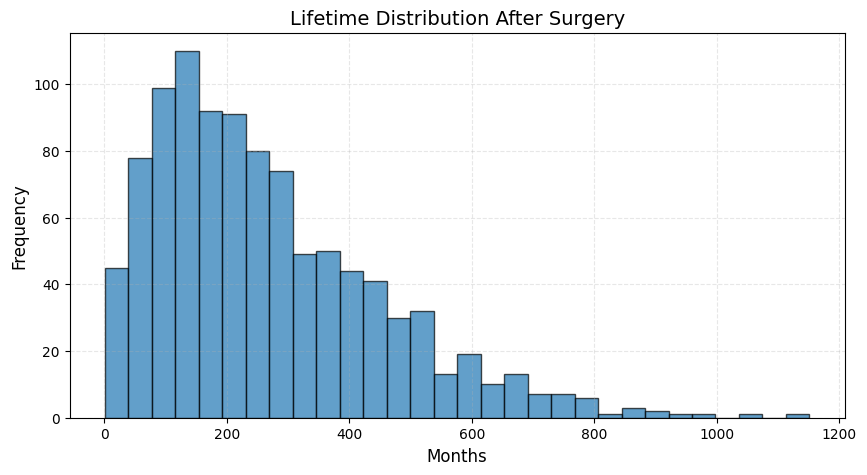

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

P = np.array([
    [0.9915, 0.005,  0.0025, 0,      0.001],
    [0,      0.986,  0.005,  0.004,  0.005],
    [0,      0,      0.992,  0.003,  0.005],
    [0,      0,      0,      0.991,  0.009],
    [0,      0,      0,      0,      1    ]
])


np.random.seed(42)
n_women = 1000
lifetimes = []
local_recurrence_count = 0

states_list = [0,1,2,3,4] 

state_120 = []

for _ in range(n_women):
    current_state = 0 
    lifetime = 0
    had_local_recurrence = False
    state_120_state = 4
    
    while current_state != 4:
        current_state = np.random.choice(states_list, p=P[current_state])
        lifetime += 1 
        
        if current_state == 1 or current_state == 3:
            had_local_recurrence = True
        
        if lifetime == 120:
            state_120_state = current_state
            
    lifetimes.append(lifetime)
    state_120.append(state_120_state)
    
    if had_local_recurrence:
        local_recurrence_count += 1


prop_women = local_recurrence_count/n_women

print(f'Proportion of women with local recurrence: {prop_women}')
plt.hist(lifetimes, bins=30, edgecolor='black', alpha=0.7)
plt.title('Lifetime Distribution After Surgery')
plt.xlabel('Months')
plt.ylabel('Frequency')
plt.show()



In [3]:
# Task 2
from scipy.stats import chisquare

t = 120

p0 = np.array([1,0,0,0,0])
#p0 = P[0,:]
pt = p0@np.linalg.matrix_power(P,t)

counts_expected = pt*1000

unique, counts = np.unique(state_120, return_counts=True)

stat, p_value = chisquare(f_obs=counts, f_exp=counts_expected)


In [4]:
print("Theoretical Probabilities (pt):", np.round(pt, 4))
print("Expected counts:", np.round(counts_expected, 2))
print("Observed counts:", counts)
print(f"Chi-square test statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

Theoretical Probabilities (pt): [0.359  0.159  0.1661 0.0677 0.2482]
Expected counts: [359.03 158.96 166.09  67.74 248.19]
Observed counts: [364 165 167  69 235]
Chi-square test statistic: 1.0280
p-value: 0.9055


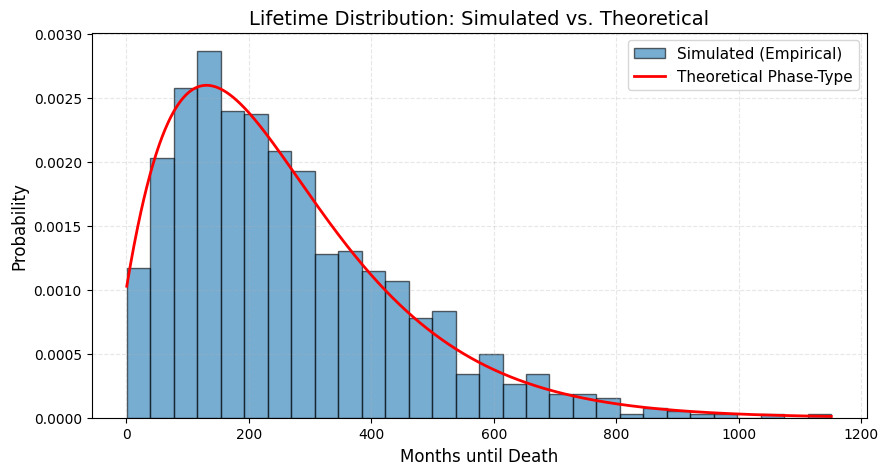

Theoretical Expected Lifetime: 262.37 months
Empirical Expected Lifetime: 265.04 months


In [ ]:
# Task 3

#pi = P[0,:4]
pi = np.array([1,0,0,0])
Ps = P[:4,:4]

ps = P[:4,4]

ones = np.ones(np.size(ps))

max_months = max(lifetimes)
t_values = np.arange(1, max_months + 1)
theoretical_pmf = []

for t in t_values:
    # Calculate P(T=t) = pi * (Ps)^(t) * ps
    prob = pi @ np.linalg.matrix_power(Ps, t ) @ ps
    theoretical_pmf.append(prob)


plt.hist(lifetimes, bins=30, density=True, alpha=0.6, edgecolor='black', label='Simulated (Empirical)')

plt.plot(t_values, theoretical_pmf, color='red', lw=2, label='Theoretical Phase-Type')

plt.title('Lifetime Distribution: Simulated vs. Theoretical')
plt.xlabel('Months until Death')
plt.ylabel('Probability')
plt.legend()
plt.show()

I = np.eye(4) 
ones = np.ones(4)
expected_lifetime = pi @ np.linalg.inv(I - Ps) @ ones
print(f"Theoretical Expected Lifetime: {expected_lifetime:.2f} months")
print(f"Empirical Expected Lifetime: {np.mean(lifetimes):.2f} months")

In [ ]:
n_women = 1000
max_months = max(lifetimes)

obs_counts_full = np.bincount(lifetimes)[1:]

if len(obs_counts_full) < len(theoretical_pmf):
    obs_counts_full = np.pad(obs_counts_full, (0, len(theoretical_pmf) - len(obs_counts_full)))

exp_counts_full = np.array(theoretical_pmf) * n_women
exp_counts_full = exp_counts_full * (np.sum(obs_counts_full) / np.sum(exp_counts_full))

obs_grouped = []
exp_grouped = []

current_obs = 0
current_exp = 0

for obs, exp in zip(obs_counts_full, exp_counts_full):
    current_obs += obs
    current_exp += exp
    
    if current_exp >= 5:
        obs_grouped.append(current_obs)
        exp_grouped.append(current_exp)
        current_obs = 0
        current_exp = 0

if current_exp > 0 and len(exp_grouped) > 0:
    obs_grouped[-1] += current_obs
    exp_grouped[-1] += current_exp

stat, p_value = chisquare(f_obs=obs_grouped, f_exp=exp_grouped)

print(f"Number of valid bins after grouping: {len(obs_grouped)}")
print(f"Chi-square test statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

Number of valid bins after grouping: 173
Chi-square test statistic: 142.4229
p-value: 0.9515


Mean of lifetimes for woman who survives first 12 month and new cancer: 177.9 months


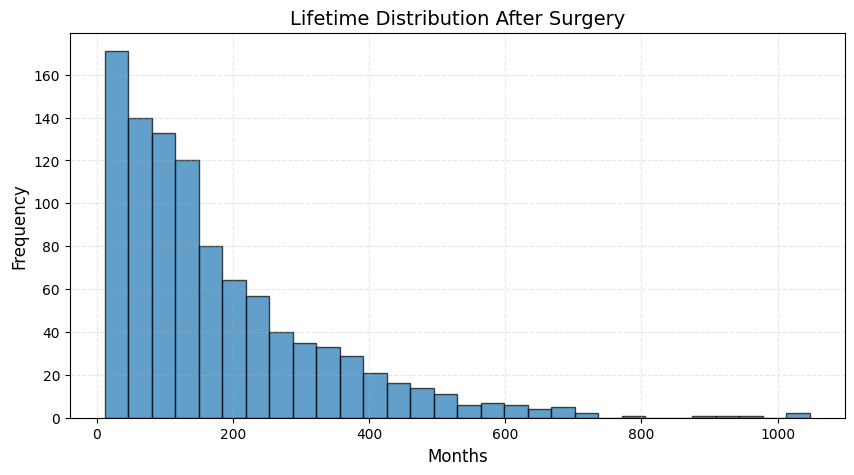

In [7]:
# Task 4

accepted_life_times = []
states_list = [0,1,2,3,4]

np.random.seed(42)

while len(accepted_life_times) < 1000:
    reapeared = False
    current_state = 0
    lifetime = 0

    while current_state != 4:
        current_state = np.random.choice(states_list, p=P[current_state])
        lifetime += 1 
        
        if lifetime <= 12:
            if (current_state == 1 or current_state == 2 or current_state == 3):
                reapeared = True
        
    if reapeared and lifetime >= 12:
        accepted_life_times.append(lifetime)
    
estimated_mean = np.mean(accepted_life_times)

print(f'Mean of lifetimes for woman who survives first 12 month and new cancer: {estimated_mean} months' )
plt.hist(accepted_life_times, bins=30, edgecolor='black', alpha=0.7)
plt.title('Lifetime Distribution After Surgery')
plt.xlabel('Months')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Task 5

expected_Z = pi @ np.linalg.inv(I - Ps) @ np.ones(4)
crude_frac = []
mean_life = []

for _ in range(100):
    lifetimes_batch = []

    for _ in range(200):
        current_state = 0
        lifetime = 0
        while current_state != 4:
            current_state = np.random.choice(states_list, p=P[current_state])
            lifetime += 1 
        lifetimes_batch.append(lifetime)

    lifetimes_batch = np.array(lifetimes_batch)

    woman_350 = np.sum(lifetimes_batch > 350) / 200

    crude_frac.append(woman_350)

    mean_lifetime = np.mean(lifetimes_batch)

    mean_life.append(mean_lifetime)

crude = np.array(crude_frac)
mean_ = np.array(mean_life)


cov_matrix = np.cov(crude, mean_)

covariance_XZ = cov_matrix[0, 1]
variance_crude = cov_matrix[1, 1]

c_optimal = -covariance_XZ / variance_crude

Y = crude + c_optimal * (mean_ - expected_Z)

var_X = np.var(crude, ddof=1)
var_Y = np.var(Y, ddof=1)
variance_reduction_percent = (1 - (var_Y / var_X)) * 100

print(f"Mean fraction dying within 350 months (Controlled): {np.mean(Y):.4f}")
print(f"Variance of Crude Estimator (X): {var_X:.6f}")
print(f"Variance of Controlled Estimator (Y): {var_Y:.6f}")
print(f"Variance Reduction: {variance_reduction_percent:.2f}%")


Mean fraction dying within 350 months (Controlled): 0.2631
Variance of Crude Estimator (X): 0.001224
Variance of Controlled Estimator (Y): 0.000352
Variance Reduction: 71.26%


Mean Lifetime: 256.37 months
95% CI for Mean:   [244.31, 268.43]
95% CI for SD:     [186.22, 203.29]
Proportion of women with distant recurrence: 0.599


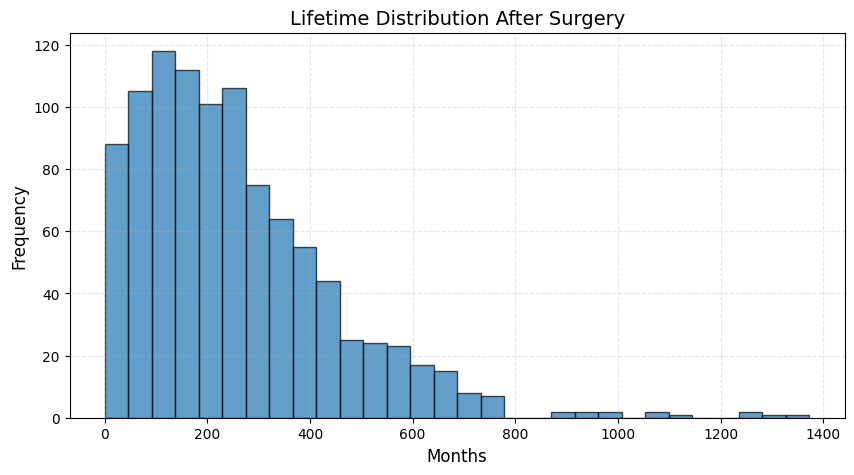

In [ ]:
# Task 7

import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.stats as stats


Q = np.array([
    [-0.0085, 0.005,  0.0025, 0,      0.001],
    [0,      -0.014,  0.005,  0.004,  0.005],
    [0,       0,     -0.008,  0.003,  0.005],
    [0,       0,      0,     -0.009,  0.009],
    
])

np.random.seed(42)
n_women = 1000
lifetimes = []
distant_recurrence_count = 0

states_list = [0,1,2,3,4] 

state_120 = []

for _ in range(n_women):
    current_state = 0 
    time = 0
    had_distant_recurrence = False
    
    while current_state != 4:
        rate = -Q[current_state, current_state]
        sojourn_time = np.random.exponential(scale = 1/rate)
        time += sojourn_time


        transition_prob = Q[current_state].copy()
        transition_prob[current_state] = 0
        transition_prob = transition_prob/rate

        current_state = np.random.choice(states_list, p = transition_prob)
        
        if current_state == 2 or current_state == 3:
            if time > 30.5:
                had_distant_recurrence = True
        
            
    lifetimes.append(time)
    
    if had_distant_recurrence:
        distant_recurrence_count += 1


lifetimes = np.array(lifetimes)
mean_lifetime = np.mean(lifetimes)
std_lifetime = np.std(lifetimes, ddof=1)
alpha = 0.05
df = n_women - 1

t_crit = stats.t.ppf(1 - alpha/2, df)
margin_of_error = t_crit * (std_lifetime / np.sqrt(n_women))
mean_ci = (mean_lifetime - margin_of_error, mean_lifetime + margin_of_error)

chi2_lower = stats.chi2.ppf(1 - alpha/2, df)
chi2_upper = stats.chi2.ppf(alpha/2, df)
var_ci_lower = (df * std_lifetime**2) / chi2_lower
var_ci_upper = (df * std_lifetime**2) / chi2_upper
std_ci = (np.sqrt(var_ci_lower), np.sqrt(var_ci_upper))

# 5. Output the results
print(f"Mean Lifetime: {mean_lifetime:.2f} months")
print(f"95% CI for Mean:   [{mean_ci[0]:.2f}, {mean_ci[1]:.2f}]")
print(f"95% CI for SD:     [{std_ci[0]:.2f}, {std_ci[1]:.2f}]")

prop_women = distant_recurrence_count/n_women

print(f'Proportion of women with distant recurrence: {prop_women}')
plt.hist(lifetimes, bins=30, edgecolor='black', alpha=0.7)
plt.title('Lifetime Distribution After Surgery')
plt.xlabel('Months')
plt.ylabel('Frequency')
plt.show()

KS Test Statistic: 0.0239
p-value: 0.6110


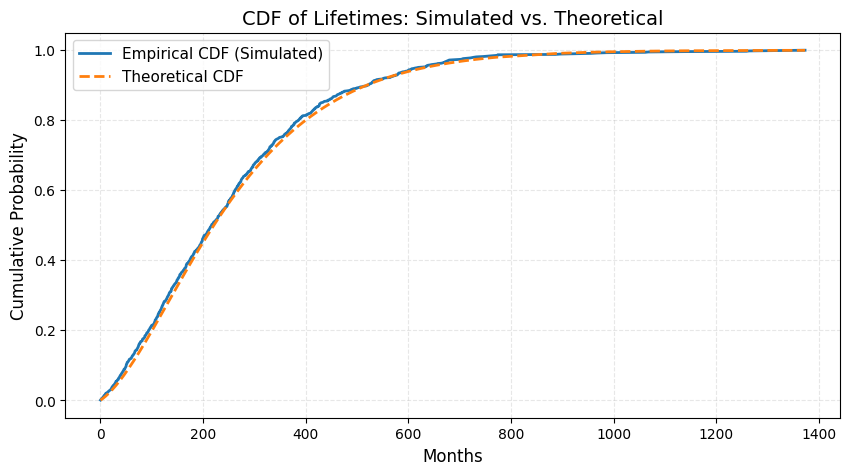

In [ ]:
# Task 8
from scipy.linalg import expm
from scipy.stats import kstest


ones = np.ones(np.size(ps))

Qs = Q[:4,:4]
p0 = np.array([1,0,0,0])

def theoretical_cdf(t_array):
    cdf_values = []
    for t in t_array:
        matrix_exp = expm(Qs * t)

        prob = 1 - (p0@matrix_exp@ones)
        cdf_values.append(prob)

    return np.array(cdf_values)


stat, p_value = kstest(lifetimes, theoretical_cdf)

print(f"KS Test Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

sorted_lifetimes = np.sort(lifetimes)
empirical_cdf = np.arange(1, len(sorted_lifetimes) + 1) / len(sorted_lifetimes)

theo_cdf_vals = theoretical_cdf(sorted_lifetimes)

plt.plot(sorted_lifetimes, empirical_cdf, label='Empirical CDF (Simulated)', linewidth=2)
plt.plot(sorted_lifetimes, theo_cdf_vals, label='Theoretical CDF', linestyle='--', linewidth=2)
plt.title('CDF of Lifetimes: Simulated vs. Theoretical')
plt.xlabel('Months')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()



mean with no treatment: 256.3715684046518
mean with treatment: 343.18143531883584


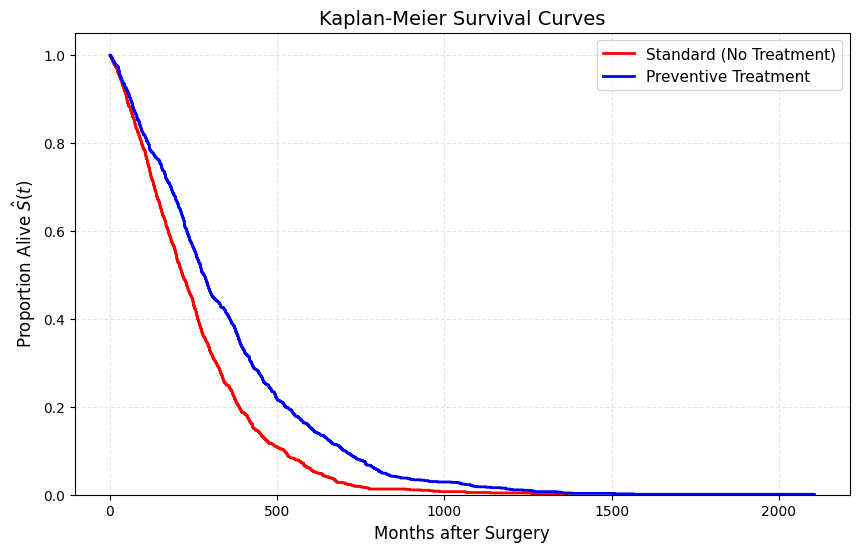

In [13]:
# Task 9

import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.stats as stats

Q_new = np.array([
    [-0.00475, 0.0025,  0.00125, 0,      0.001],
    [0,      -0.007,  0,  0.002,  0.005],
    [0,       0,     -0.008,  0.003,  0.005],
    [0,       0,      0,     -0.009,  0.009],
    [0,       0,       0,      0,     0]
])


np.random.seed(42)
n_women = 1000
lifetimes_new = []
distant_recurrence_count_new = 0

states_list = [0,1,2,3,4] 

state_120 = []

for _ in range(n_women):
    current_state = 0 
    time = 0
    had_distant_recurrence = False
    
    while current_state != 4:
        rate = -Q_new[current_state, current_state]
        sojourn_time = np.random.exponential(scale = 1/rate)
        time += sojourn_time


        transition_prob = Q_new[current_state].copy()
        transition_prob[current_state] = 0
        transition_prob = transition_prob/rate

        current_state = np.random.choice(states_list, p = transition_prob)
        
        if current_state == 2 or current_state == 3:
            if time > 30.5:
                had_distant_recurrence = True
        
            
    lifetimes_new.append(time)
    
    if had_distant_recurrence:
        distant_recurrence_count_new += 1


lifetimes_new = np.array(lifetimes_new)

mean_no_treat = np.mean(lifetimes)
mean_treat = np.mean(lifetimes_new)

print(f'mean with no treatment: {mean_no_treat}')
print(f'mean with treatment: {mean_treat}')


def plot_kaplan_meier(lifetimes, label, color):
    sorted_lifetimes = np.sort(lifetimes)
    proportions_alive = 1 - np.arange(1, len(lifetimes) + 1) / len(lifetimes)
    
    plt.step(sorted_lifetimes, proportions_alive, where='post', label=label, color=color, linewidth=2)

plt.figure(figsize=(10, 6))

# Plot both curves
plot_kaplan_meier(lifetimes, label='Standard (No Treatment)', color='red')
plot_kaplan_meier(lifetimes_new, label='Preventive Treatment', color='blue')

plt.title('Kaplan-Meier Survival Curves')
plt.xlabel('Months after Surgery')
plt.ylabel('Proportion Alive $\hat{S}(t)$')
plt.ylim([0, 1.05])
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
from lifelines.statistics import logrank_test

events_standard = np.ones(len(lifetimes))
events_new = np.ones(len(lifetimes_new))

results = logrank_test(
    durations_A=lifetimes, 
    durations_B=lifetimes_new, 
    event_observed_A=events_standard, 
    event_observed_B=events_new
)

# Print the results
print(f"Test Statistic: {results.test_statistic:.4f}")
print(f"p-value: {results.p_value:.4e}")

Test Statistic: 75.0161
p-value: 4.6690e-18


In [23]:
# Task 12

import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.stats as stats

Q_new = np.array([
    [-0.00475, 0.0025,  0.00125, 0,      0.001],
    [0,      -0.007,  0,  0.002,  0.005],
    [0,       0,     -0.008,  0.003,  0.005],
    [0,       0,      0,     -0.009,  0.009],
    [0,       0,       0,      0,     0]
])


np.random.seed(42)
n_women = 1000
lifetimes_new = []
monitoring = []

states_list = [0,1,2,3,4] 


for _ in range(n_women):
    current_state = 0 
    time = 0
    monitoring_woman = []
    next_checkup = 0
    
    while current_state != 4:
        rate = -Q_new[current_state, current_state]
        sojourn_time = np.random.exponential(scale = 1/rate)

        while time + sojourn_time >= next_checkup:
            monitoring_woman.append(current_state)
            next_checkup += 48

        time += sojourn_time

        transition_prob = Q_new[current_state].copy()
        transition_prob[current_state] = 0
        transition_prob = transition_prob/rate


        current_state = np.random.choice(states_list, p = transition_prob)

        
    monitoring_woman.append(4)

    lifetimes_new.append(time)
    monitoring.append(monitoring_woman)

Y = monitoring
    

print("Example observations for the first 3 women:")
for i in range(7):
    print(f"Woman {i+1}: {monitoring[i]}")

Example observations for the first 3 women:
Woman 1: [0, 0, 0, 4]
Woman 2: [0, 0, 0, 0, 0, 0, 2, 4]
Woman 3: [0, 0, 0, 0, 0, 4]
Woman 4: [0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 4]
Woman 5: [0, 0, 0, 1, 1, 1, 3, 4]
Woman 6: [0, 0, 0, 2, 4]
Woman 7: [0, 0, 0, 0, 1, 1, 1, 4]


In [ ]:
# Task 13


def find_Q(Q_initial, data):
    converged = False
    Q_current = Q_initial.copy()
    states_list = [0, 1, 2, 3, 4]

    while not converged:
        N_ij = np.zeros((5, 5))
        S_i = np.zeros(5)

        for woman_obs in data:
            for step in range(len(woman_obs) - 1):
                start_state = woman_obs[step]
                end_state = woman_obs[step + 1]

                accepted = False

                while not accepted:
                    current_state = start_state
                    time = 0

                    temp_N_ij = np.zeros((5, 5))
                    temp_S_i = np.zeros(5)

                    while time < 48:
                        rate = -Q_current[current_state, current_state]

                        if current_state == 4:
                            temp_S_i[current_state] += 48 - time
                            time = 48
                            break

                        sojourn_time = np.random.exponential(scale=1/rate)

                        if time + sojourn_time >= 48:
                            temp_S_i[current_state] += 48 - time
                            time = 48
                            break
                        else:
                            temp_S_i[current_state] += sojourn_time
                            time += sojourn_time
                            
                            transition_probs = Q_current[current_state].copy()
                            transition_probs[current_state] = 0
                            transition_probs = transition_probs / rate
                            
                            next_state = np.random.choice(states_list, p=transition_probs)
                            temp_N_ij[current_state, next_state] += 1
                            current_state = next_state
                    
                    if current_state == end_state:
                        accepted = True
                        N_ij += temp_N_ij
                        S_i += temp_S_i

        Q_next = np.zeros((5, 5))
        for i in range(4):
            for j in range(5):
                if i != j:
                    Q_next[i, j] = N_ij[i, j] / S_i[i] if S_i[i] > 0 else 0
        
            Q_next[i, i] = -np.sum(Q_next[i])
            
        max_diff = np.max(np.abs(Q_current - Q_next))
        print(f"Max difference this iteration: {max_diff:.5f}")
        
        if max_diff < 1e-3:
            converged = True
        
        Q_current = np.copy(Q_next)
    
    return Q_current


Q_curr = find_Q(Q_new, Y)

print("Estimated Q Matrix:")
print(np.round(Q_curr, 4))
print(np.round(Q_new, 4))




Max difference this iteration: 0.00032
Estimated Q Matrix:
[[-0.0047  0.0025  0.0012  0.      0.001 ]
 [ 0.     -0.0073  0.      0.0022  0.0052]
 [ 0.      0.     -0.0078  0.0029  0.0049]
 [ 0.      0.      0.     -0.0092  0.0092]
 [ 0.      0.      0.      0.      0.    ]]
[[-0.0048  0.0025  0.0012  0.      0.001 ]
 [ 0.     -0.007   0.      0.002   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]


In [33]:
# Naive initial guess Q^(0)
Q_initial = np.array([
    [-0.03,  0.01,  0.01,  0.00,  0.01],  
    [ 0.00, -0.02,  0.00,  0.01,  0.01], 
    [ 0.00,  0.00, -0.02,  0.01,  0.01],  
    [ 0.00,  0.00,  0.00, -0.01,  0.01],  
    [ 0.00,  0.00,  0.00,  0.00,  0.00]   
])

print("Starting MCEM Optimization from Naive Guess...\n")
Q_curr = find_Q(Q_initial, Y)

print("\n" + "="*50)
print("FINAL ESTIMATED Q MATRIX (Started from Naive Guess):")
print(np.round(Q_curr, 4))
print("\nORIGINAL TRUE Q_NEW MATRIX:")
print(np.round(Q_new, 4))
print("="*50)

Starting MCEM Optimization from Naive Guess...

Max difference this iteration: 0.02520
Max difference this iteration: 0.00137
Max difference this iteration: 0.00045

FINAL ESTIMATED Q MATRIX (Started from Naive Guess):
[[-0.0047  0.0024  0.0013  0.      0.0011]
 [ 0.     -0.0071  0.      0.0023  0.0048]
 [ 0.      0.     -0.0079  0.0026  0.0053]
 [ 0.      0.      0.     -0.0092  0.0092]
 [ 0.      0.      0.      0.      0.    ]]

ORIGINAL TRUE Q_NEW MATRIX:
[[-0.0048  0.0025  0.0012  0.      0.001 ]
 [ 0.     -0.007   0.      0.002   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]
